In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
import statsmodels
import statsmodels.sandbox.stats.multicomp
import pandas as pd
from statsmodels.stats.weightstats import ztest
import seaborn as sns

import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.utils import shuffle
import hashlib
from base64 import b64encode
import collections

# Почему нельзя многократно применять обычные тесты

Посмотрим, что будет, если многократно применять обычный t-test к данным "одного" эксперимента:

Сначала посмотрим, какой эффект мы сможем поймать на данных, чтобы докидывать его при наших экспериментах

In [ ]:
def get_mde(metric_std, metric_n, metric_mean, alpha=0.05, beta=0.2):

    #metric_mean, metric_std, metric_n = metric_vec.mean(), metric_vec.std(), metric_vec.count()

    z_alpha = norm.ppf(1-(alpha / 2), loc=0, scale=1)
    z_beta = norm.ppf(1-beta, loc=0, scale=1)

    mde = (z_alpha + z_beta)*np.sqrt(2)*metric_std / np.sqrt(metric_n)

    return mde*100/metric_mean

In [ ]:
get_mde(1, 500, 5, alpha=0.05, beta=0.2)

Теперь сгенерируем данные, учитывая эффект и другие параметры, а потом проведем несколько раз t-test, как при проверке корректности критерия

In [ ]:
for _ in range(10):
    false_positive = []
    true_positive = []
    for _ in range(1000):
        vec_a = np.random.normal(5, 1, 250)
        vec_b_no_effect = np.random.normal(5, 1, 250)
        vec_b_with_effect = np.random.normal(5 * 1.035, 1, 250)
        _, pv_identical = stats.ttest_ind(vec_a, vec_b_no_effect)
        _, pv_effect = stats.ttest_ind(vec_a, vec_b_with_effect)
        false_positive.append(int(pv_identical < 0.05))
        true_positive.append(int(pv_effect < 0.05))
    print()
    print(f'I type error  : {np.mean(false_positive):0.3f}')
    print(f'II type error : {1 - np.mean(true_positive):0.3f}')

За исключением некоторых "выбросов" ошибка 1 рода не сильно выше заданного порога

Теперь попробуем добавлять данные в выборки и проводить тест

In [ ]:
def sequential_ttest(vec_a, vec_b, alpha):
    min_vec = min(len(vec_a), len(vec_b))
    for i in range(2, min_vec, 10): # для быстроты счета будем добавлять по несколько наблюдений сразу (аналог добавления данных батчами)
        vec_a_reduced = vec_a[:i]
        vec_b_reduced = vec_b[:i]
        _, pv = stats.ttest_ind(vec_a_reduced, vec_b_reduced)
        if pv < alpha: # если видим значимые различия, то возвращаем 1, если нет, то 0
            return 1
    return 0

In [ ]:
for _ in range(10):
    false_positive = []
    true_positive = []
    for _ in range(500):
        vec_a = np.random.normal(5, 1, 250)
        vec_b_no_effect = np.random.normal(5, 1, 250)
        vec_b_with_effect = np.random.normal(5 * 1.035, 1, 250)
        false_positive.append(sequential_ttest(vec_a, vec_b_no_effect, 0.05))
        true_positive.append(sequential_ttest(vec_a, vec_b_with_effect, 0.05))
    print()
    print(f'I type error  : {np.mean(false_positive):0.3f}')
    print(f'II type error : {1 - np.mean(true_positive):0.3f}')

Видим, что теперь ошибка 1 рода сильно выросла. Почему так получилось?

# Метод Вальда (классический)

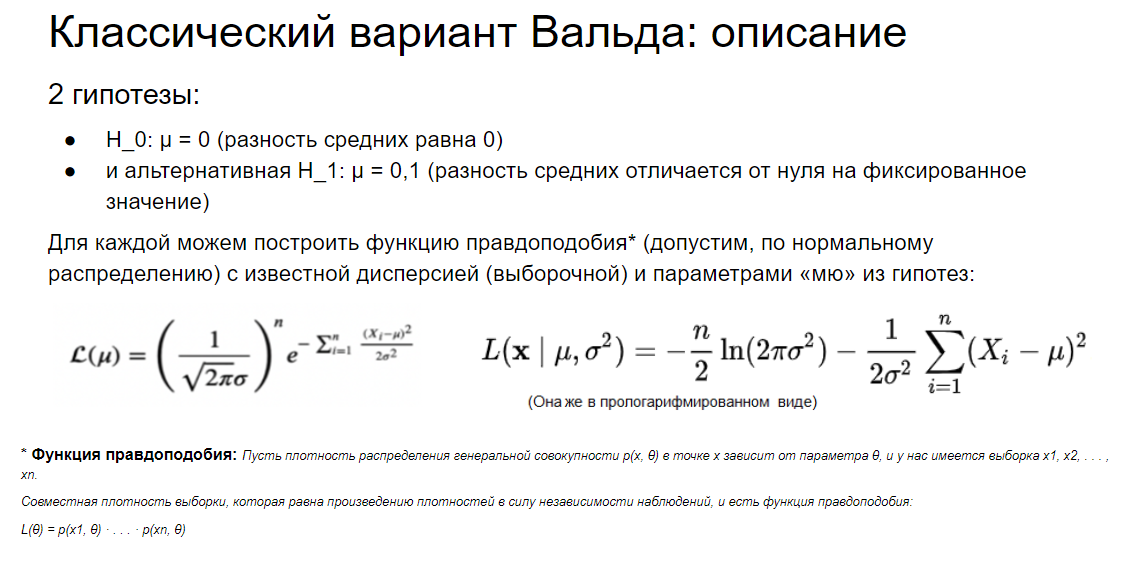

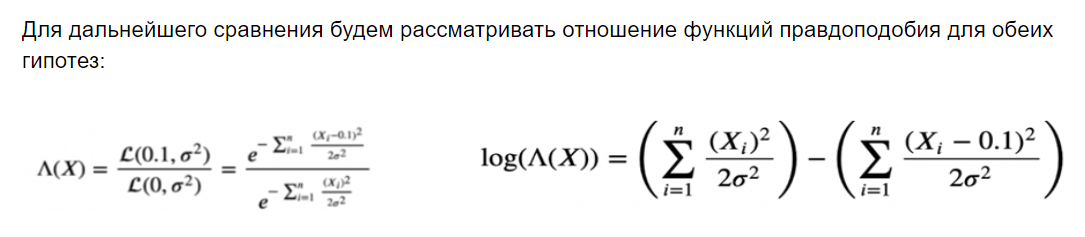

In [ ]:
# Создадим класс, реализующий логику метода Вальда

class WaldSequentialAnalysis:
    def __init__(self, mean, std, effect, alpha, beta):
        self.mean = mean
        self.std = std
        self.effect = effect
        self.alpha = alpha
        self.beta = beta
        self.lower_bound = np.log(beta / (1 - alpha)) # здесь мы вычисляем границы
        self.upper_bound = np.log((1 - beta) / alpha)

    def log_pdf_one(self, x):
        """Логарифм функции плотности разницы средних при верности нулевой гипотезы."""
        return stats.norm.logpdf(x, 0, np.sqrt(2) * self.std)

    def log_pdf_two(self, x):
        """Логарифм функции плотности разницы средних при верности альтернативной гипотезы."""
        return stats.norm.logpdf(x, self.mean * (self.effect - 1), np.sqrt(2) * self.std)

    def test(self, data_one, data_two):
        """Проверяет наличие значимых отличий по мере поступления данных."""
        min_len = min(len(data_one), len(data_two))
        for i in range(1, min_len):
            sub_data_one = data_one[:i]
            sub_data_two = data_two[:i]
            delta_sub_data = sub_data_two - sub_data_one
            log_pdf_one_values = self.log_pdf_one(delta_sub_data)
            log_pdf_two_values = self.log_pdf_two(delta_sub_data)
            z = np.sum(log_pdf_two_values - log_pdf_one_values)
            # далее будем проверять условия остановки
            if z < self.lower_bound:
                return 0, i
            if z > self.upper_bound:
                return 1, i
        return 0.5, i



In [ ]:
# Функция для отрисовки теста
def plot_wald_test(wald_test, data_one, data_two):
    fig, ax = plt.subplots(figsize=(10, 6))

    zs = []
    for i in range(1, len(data_one)):
        sub_data_one = data_one[:i]
        sub_data_two = data_two[:i]
        delta_sub_data = sub_data_two - sub_data_one
        log_pdf_one_values = wald_test.log_pdf_one(delta_sub_data)
        log_pdf_two_values = wald_test.log_pdf_two(delta_sub_data)
        z = np.sum(log_pdf_two_values - log_pdf_one_values)
        zs.append(z)

    result, stop_point = wald_test.test(data_one, data_two)
    ax.plot(zs, label='Статистика Z', color='blue')
    ax.axhline(wald_test.upper_bound, color='red', linestyle='--', label='Верхняя граница')
    ax.axhline(wald_test.lower_bound, color='green', linestyle='--', label='Нижняя граница')
    ax.axvline(stop_point, color='orange', linestyle='-.', label=f'Прекращение на шаге {stop_point}')

    ax.set_xlabel('Количество наблюдений')
    ax.set_ylabel('Сумма логарифмов правдоподобий')
    ax.set_title('Вальдовский процесс последовательного анализа')
    ax.legend()
    plt.show()

    # График 2: Сравнение распределений
    plt.subplot(2, 1, 1)
    plt.hist(data_one, bins=30, alpha=0.5, label='Группа 1')
    plt.hist(data_two, bins=30, alpha=0.5, label='Группа 2')
    plt.axvline(np.mean(data_one), color='b', linestyle='--')
    plt.axvline(np.mean(data_two), color='r', linestyle='--')
    plt.title('Распределение данных')
    plt.legend()

Посмотрим, как это работает

In [ ]:
mean = 5
std = 1
effect = 1.05
alpha = 0.05
beta = 0.2
sample_size_ = 250

data_a = np.random.normal(mean, std, sample_size_)
data_b_one = np.random.normal(mean, std, sample_size_)
data_b_two = np.random.normal(mean * effect, std, sample_size_)

wald = WaldSequentialAnalysis(mean, std, effect, alpha, beta)
result_no_effect, n_steps_no_effect = wald.test(data_a, data_b_one)

In [ ]:
result_no_effect, n_steps_no_effect

In [ ]:
plot_wald_test(wald, data_a, data_b_one)

In [ ]:
result_effect, n_steps_effect = wald.test(data_a, data_b_two)
result_effect, n_steps_effect

In [ ]:
plot_wald_test(wald, data_a, data_b_two)

# Сравним мощности метода Вальда и стандартного теста Стьюдента

На лекции мы говорили о сравнении мощностей t-test и always valid p-values, теперь сами проверим классический метод Вальда

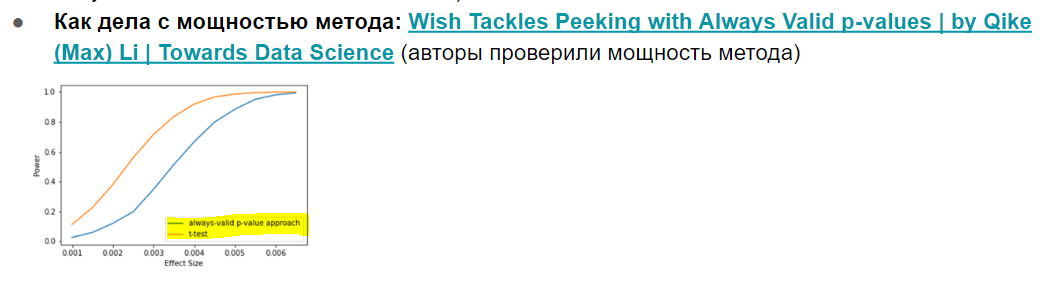

In [ ]:
def compare_wald_ttest(mean, std, effect, sample_size, n_simulations=1000, alpha = 0.05, beta = 0.2):
    # Инициализация анализатора Вальда
    wald = WaldSequentialAnalysis(mean, std, effect, alpha, beta)

    # Массивы для хранения результатов
    wald_decisions = []
    wald_samples = []
    ttest_decisions = []

    for _ in range(n_simulations):
        # Генерация данных
        control = np.random.normal(mean, std, sample_size)
        test = np.random.normal(mean * effect, std, sample_size)

        # Анализ методом Вальда
        wald_decision, wald_n = wald.test(control, test)
        wald_decisions.append(wald_decision)
        wald_samples.append(wald_n)

        # t-тест
        _, p_value = stats.ttest_ind(control, test)
        ttest_decisions.append(1 if p_value < alpha else 0)

    # Построение графиков
    plt.figure(figsize=(15, 5))

    # График 1: Распределение количества шагов (объема данных) для метода Вальда
    plt.subplot(131)
    plt.hist(wald_samples, bins=30)
    plt.title('Распределение количества шагов\nWald Sequential Analysis')
    plt.xlabel('Количество шагов')
    plt.ylabel('Частота')

    # График 2: Сравнение решений
    plt.subplot(132)
    labels = ['Отклонить H0', 'Принять H0', 'Нет решения']
    wald_counts = [
        sum(1 for x in wald_decisions if x == 1),
        sum(1 for x in wald_decisions if x == 0),
        sum(1 for x in wald_decisions if x == 0.5)
    ]
    ttest_counts = [
        sum(1 for x in ttest_decisions if x == 1),
        sum(1 for x in ttest_decisions if x == 0),
        0
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.bar(x - width/2, wald_counts, width, label='Wald')
    plt.bar(x + width/2, ttest_counts, width, label='t-test')
    plt.xlabel('Вердикт')
    plt.ylabel('Количество')
    plt.title('Сравнение вердиктов')
    plt.xticks(x, labels)
    plt.legend()

    # График 3: Среднее количество шагов (объем данных)
    plt.subplot(133)
    plt.boxplot([wald_samples])
    plt.axhline(y=sample_size, color='r', linestyle='--', label='t-test (fixed)')
    plt.title('Требуемый размер выборки')
    plt.ylabel('Количество шагов')
    plt.xticks([1], ['Wald'])

    plt.tight_layout()
    plt.show()

    # Вывод статистики
    print(f"Среднее необходимое количество шагов (Wald): {np.mean(wald_samples):.2f}")
    print(f"Фиксированные выборки (t-test): {sample_size}")
    print(f"\nВердикты Вальда:")
    print(f"Отклонить H0: {wald_counts[0]/n_simulations*100:.1f}%")
    print(f"Принять H0: {wald_counts[1]/n_simulations*100:.1f}%")
    print(f"Нет решения: {wald_counts[2]/n_simulations*100:.1f}%")
    print(f"\nВердикты по t-test:")
    print(f"Отклонить H0: {ttest_counts[0]/n_simulations*100:.1f}%")
    print(f"Принять H0: {ttest_counts[1]/n_simulations*100:.1f}%")

# Запуск сравнения
compare_wald_ttest(5, 1, 1.1, 500)

In [ ]:
compare_wald_ttest(5, 1, 1.05, 500)

In [ ]:
compare_wald_ttest(5, 1, 1.01, 500)

Теперь проверим, насколько контролируется ошибка 1 рода в классическом подходе Вальда

В лекции рассматривали контроль ошибки 1 рода для always valid p-values, там все было хорошо

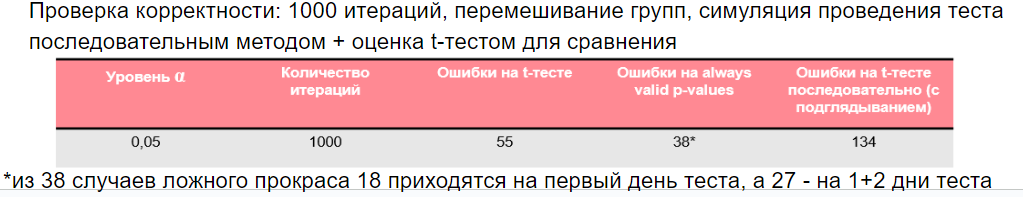

In [ ]:
np.random.seed(42)

mean = 5
std = 1
effect = 1.05
alpha = 0.05
beta = 0.2

sample_size_ = 1000

for _ in range(10):
    false_positive = []
    true_positive = []
    list_length_aa = []
    list_length_ab = []
    for _ in range(500):
        data_a = np.random.normal(mean, std, sample_size_)
        data_b_one = np.random.normal(mean, std, sample_size_)
        data_b_two = np.random.normal(mean * effect, std, sample_size_)
        wald = WaldSequentialAnalysis(
            mean, std, effect, alpha, beta
        )
        test_result_aa, length_aa = wald.test(data_a, data_b_one)
        test_result_ab, length_ab = wald.test(
            data_a, data_b_two
        )
        false_positive.append(test_result_aa)
        true_positive.append(test_result_ab)
        list_length_aa.append(length_aa)
        list_length_ab.append(length_ab)
    print()
    print(f'I type error  : {np.mean(false_positive):0.3f}')
    print(f'II type error : {1 - np.mean(true_positive):0.3f}')

Видим, что ошибка 1 рода не растет по мере увеличения количества тестов, метод Вальда контролирует ошибку

#А теперь упрощенная версия - библиотека SPRT

In [ ]:
pip install sprt

  Preparing metadata (setup.py) ... done
  Created wheel for sprt: filename=sprt-0.0.1-py3-none-any.whl size=4017 sha256=c371fbfc2a5c46b979f5594a2f305ad07b6c24ab2ea599742eb82c1e658369e2
  Stored in directory: /root/.cache/pip/wheels/3f/92/36/ba6d367bff54c2fedb2716d31c782aa4cb0d94c8a85eb8d2a4
Successfully built sprt


In [ ]:
import sprt

[Ссылка на гитхаб с библиотекой](https://github.com/Testispuncher/Sequential-Probability-Ratio-Test)

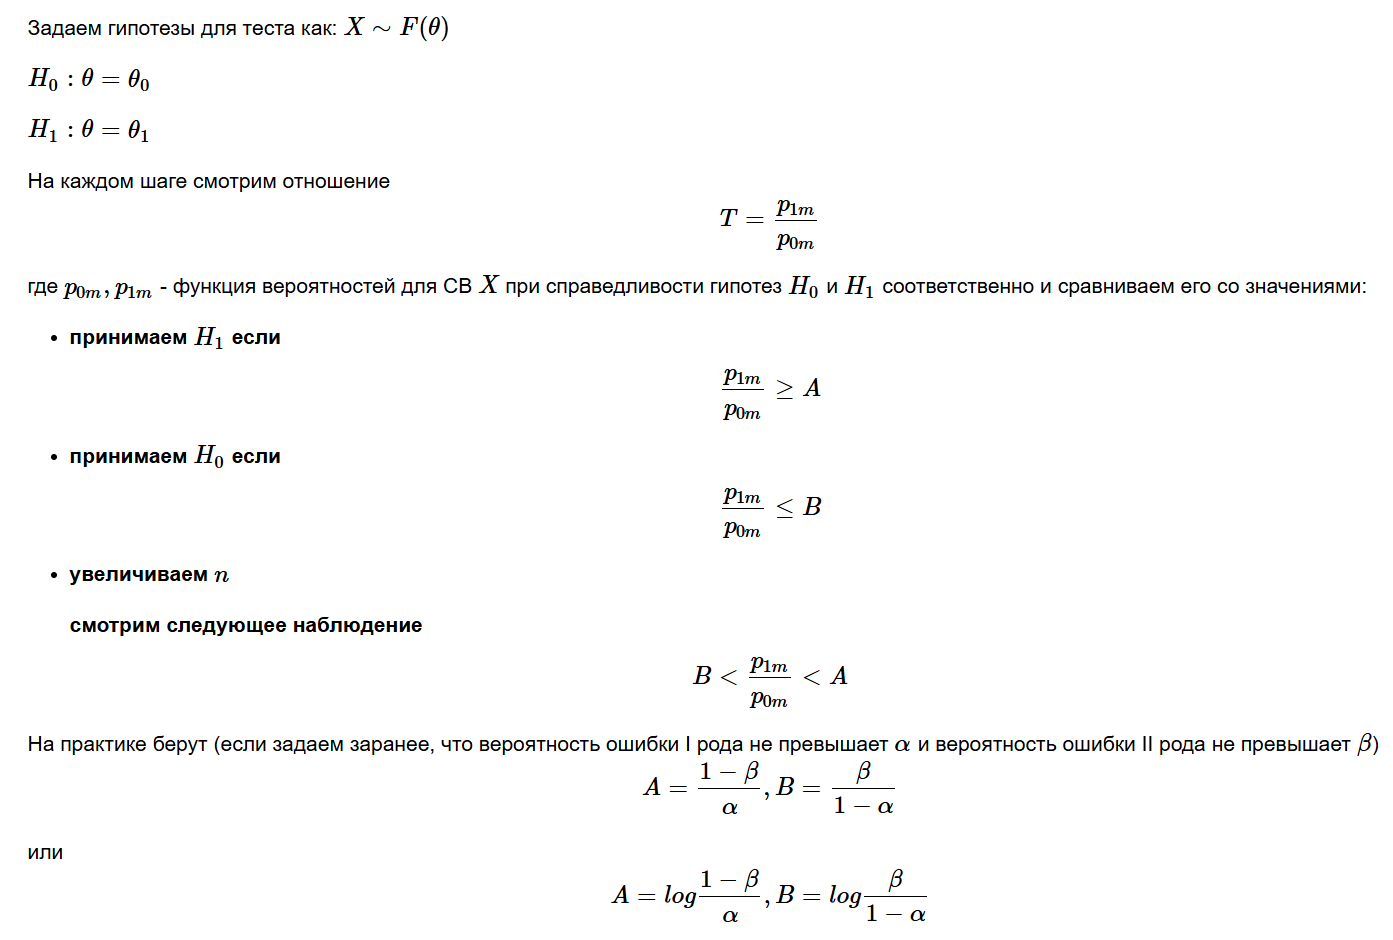

# Пример для биномиального распределения

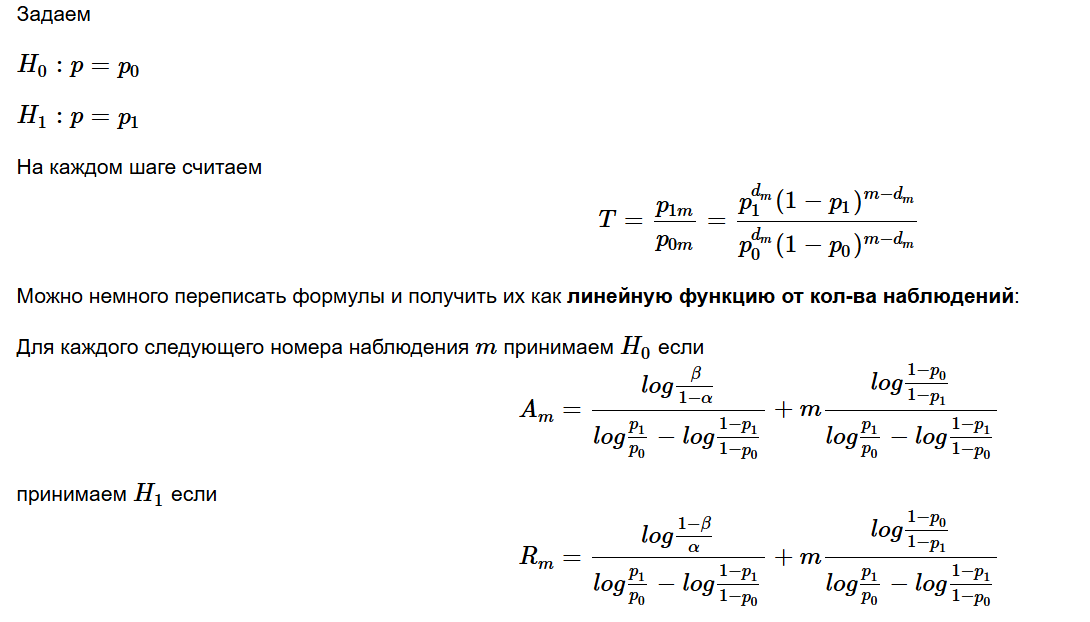

In [ ]:
# значение ф-и вероятности p0 для Н0
p0 = 0.4
# aзначение ф-и вероятности p1 для Н1
p1 = 0.6

# параметр ошибки I рода
alpha = 0.05
# параметр ошибки II рода
beta = 0.2

# сгенерируем наблюдения биномиальным распределением
values = np.random.binomial(1, 0.35, 30)
binomial_test = sprt.SPRTBinomial(values=values, h0=p0, h1=p1, alpha=alpha, beta=beta)
binomial_test.plot()

In [ ]:
values[:10]

In [ ]:
# значение ф-и вероятности p0 для Н0
p0 = 0.4
# значение ф-и вероятности p1 для Н1
p1 = 0.6

# параметр ошибки I рода
alpha = 0.05
# параметр ошибки II рода
beta = 0.2

# сгенерируем наблюдения биномиальным распределением
values = np.random.binomial(1, 0.7, 30)

binomial_test = sprt.SPRTBinomial(values=values, h0=p0, h1=p1, alpha=alpha, beta=beta)

binomial_test.plot()

Уменьшим количество наблюдений, сохранив параметры распределения и вероятности неизменными

In [ ]:
# значение ф-и вероятности p0 для Н0
p0 = 0.4
# значение ф-и вероятности p1 для Н1
p1 = 0.6

# параметр ошибки I рода
alpha = 0.05
# параметр ошибки II рода
beta = 0.2

# сгенерируем наблюдения биномиальным распределением
values = np.random.binomial(1, 0.7, 5)

binomial_test = sprt.SPRTBinomial(values=values, h0=p0, h1=p1, alpha=alpha, beta=beta)

binomial_test.plot()

То же самое можно проделать и для нормального распределения

In [ ]:
test = sprt.SPRTNormal(alpha = 0.05, beta = 0.2, h0 = 0, h1 = 0.8,
values = np.random.normal(0, 1, 100),
variance = 1)

In [ ]:
test.plot()